# Feature Evaluation — CME Futures

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against the 5-day forward return label. Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Assess predictive content via HAC-adjusted Information Coefficients
- Apply Benjamini-Hochberg FDR correction for multiple testing
- Diagnose feature shape (quantile monotonicity) and redundancy (pairwise correlation)
- Triage features as PROCEED / REVISE / STOP for downstream modeling

**Book Reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation)
and Section 7.4 (Search accounting and multiple testing). Chapter 8.6 is the
secondary reference for search control.

**Prerequisites**: Run `03_financial_features.py` and `04_model_based_features.py` first.

In [1]:
"""Feature Evaluation - CME Futures

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.
"""

import re
import warnings
from datetime import date

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots

import utils.style as style
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS

In [2]:
MAX_SYMBOLS = 0

## Configuration

Every threshold the screens, the triage rule and the figure subtitles refer to is
bound once here. A threshold retyped into a markdown table is a second source of
truth for a decision the code has already made.

In [3]:
CASE_STUDY_ID = "cme_futures"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

SETUP = load_setup_config(CASE_STUDY_ID)
eval_config = SETUP["evaluation"]

# The label and its horizon come from setup.yaml. The HAC bandwidth is the label
# horizon: it is the overlap the daily-sampled forward return induces, so typing
# it separately would let the correction and the label drift apart.
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
HAC_MAXLAGS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))

FDR_ALPHA = 0.05  # Benjamini-Hochberg level
NAIVE_T = 1.96  # two-sided normal critical value, for the naive-versus-HAC comparison
REDUNDANCY_CUT = 0.7  # |rho| above which two features are reported as one piece of evidence
MIN_SIGN_CONSISTENCY = 0.60  # fold-sign agreement the exploration arm requires
IC_THRESHOLD = 0.008  # |IC| the exploration arm requires, at a weekly horizon
N_QUANTILES = 5
MIN_COVERAGE = 0.70  # non-null fraction the correctness gate requires
MAX_STALENESS = 0.50  # unchanged-from-prior-date fraction the correctness gate allows

## Load Artifacts and Build Evaluation Panel

We combine three upstream artifacts:
- **Financial features** (`features/financial.parquet`): ~60 features from Ch8
- **Temporal features** (`features/model_based.parquet`): 9 features from Ch9
- **Primary label** (`labels/fwd_ret_5d.parquet`): 5-day forward return

CME futures data includes three contract positions per product (front month,
first deferred, second deferred). For cross-sectional IC evaluation we
**filter to front-month (position 0) only** — the three positions for the
same product share carry features and highly correlated price dynamics,
so including all three inflates the effective cross-section from 30
independent products to ~90 dependent entities, making t-statistics too
liberal. This matches the approach in `03_financial_features.py`'s inline evaluation.

**Holdout sealing.** Every statistic in this notebook — IC ranking, HAC
significance, BH-FDR discovery, and the PROCEED/STOP triage — is a feature-
selection input for Ch11. We therefore seal the evaluation to
`[START, holdout_start)` (`holdout_start` from `setup.yaml`); the holdout is
never touched here so it stays unbiased for the final model assessment
downstream.

**The fold contract for the Ch9 features.** `model_based.parquet` carries one
row per `(timestamp, product, position, fold)`, and for the two fitted families
the value depends on the fold. They do not depend on it the same way.
`04_model_based_features` fits the HMM on each fold's *training* window and then
forward-filters it over train and validation together (`04:669`), so a
training-date probability is in-sample: the transition matrix behind it was
estimated from a window that extends past that date. The ARIMA is a walk-forward
one-step-ahead `cross_validation` inside the fold window (`04:319-326`), so after
its burn-in every value is a forecast made from data strictly earlier than the
date it sits on, on training dates as much as on validation dates.

The fold column is therefore resolved rather than dropped: a fitted feature is
read only inside the validation window of the fold that produced it. That is
forced by the HMM, and for the ARIMA it is what puts the two families on one
frame. The fold-invariant FFT features, which carry no fitted parameter, are read
from any fold once that invariance is asserted.

**The evaluation frame is the union of the validation windows**, not the whole
pre-holdout span, and the Ch8 features are screened on the same rows as the Ch9
ones. Two things force it. A fitted feature exists out of sample only inside its
own validation window, so on the full span its coverage is only the share of
dates the folds happen to cover, and the coverage screen would report a design
property as a broken feature. And an IC measured over the whole span is not
comparable with one measured over the folds alone, so a ranking that mixes them
ranks the window as much as the feature. The frame is contiguous because the five
windows abut, and `generate_cv_splits` has already dropped the validation dates
whose label endpoint would reach the holdout, so the seal below is on the label
endpoint rather than on the signal date.

In [4]:
# Load features — filter to front month for evaluation
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet").filter(
    pl.col("position") == 0
)
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet").filter(
    pl.col("position") == 0
)

# Load primary label (front month only)
label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet").filter(
    pl.col("position") == 0
)
label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

# Holdout boundary — feature evaluation and triage must be sealed against the
# holdout (setup.yaml `holdout_start`). Any IC ranking, FDR discovery, or
# PROCEED/STOP decision computed with holdout data leaks the sealed window into
# feature selection, so we evaluate strictly on [START, holdout_start).
HOLDOUT_START = date(*map(int, eval_config["holdout_start"].split("-")))

# Join keys — position is fixed at 0 but kept for join consistency
JOIN_COLS = ["timestamp", "product", "position"]
DATE_COL = "timestamp"

### The walk-forward folds

Derived through `generate_cv_splits` from the label frame, which is the call
`04_model_based_features` makes and the one `load_modeling_dataset` makes in
Ch11. Replaying a fold boundary from a literal here would let the fold ids in
`model_based.parquet` mean something different on the two sides of the join,
which is what the resolution below depends on.

In [5]:
splits = generate_cv_splits(
    label_df.select(DATE_COL).unique().sort(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


for split in splits:
    print(
        f"  Fold {split['fold']}: train {_as_date(split['train_start'])} → "
        f"{_as_date(split['train_end'])}, validation {_as_date(split['val_start'])} → "
        f"{_as_date(split['val_end'])}"
    )

  Fold 0: train 2015-01-05 → 2022-12-22, validation 2023-01-03 → 2023-12-21
  Fold 1: train 2014-01-03 → 2021-12-23, validation 2022-01-03 → 2022-12-30
  Fold 2: train 2013-01-01 → 2020-12-24, validation 2021-01-05 → 2021-12-31
  Fold 3: train 2012-01-04 → 2019-12-26, validation 2020-01-06 → 2021-01-04
  Fold 4: train 2011-01-05 → 2018-12-26, validation 2019-01-04 → 2020-01-03


In [6]:
# Resolve the fold column. FFT carries no fitted parameter and 04 replicates one
# set of values across every fold; assert that rather than assume it, then read it
# once. ARIMA and HMM are fitted per fold, so each value is kept only inside the
# validation window of the fold that produced it — the rows where it is genuinely
# out of sample.
FITTED_PREFIXES = ("arima_", "hmm_")
# The artifact as written, one row per (key, fold), kept for the quality gate: the
# rows this notebook does not screen are still rows Ch11 trains on.
temporal_artifact = temporal
temporal_feature_cols = [c for c in temporal.columns if c not in (*JOIN_COLS, "fold")]
invariant_cols = [c for c in temporal_feature_cols if not c.startswith(FITTED_PREFIXES)]
fitted_cols = [c for c in temporal_feature_cols if c.startswith(FITTED_PREFIXES)]

folds = sorted(temporal["fold"].unique().to_list())
_reference = temporal.filter(pl.col("fold") == folds[0]).select([*JOIN_COLS, *invariant_cols])
for fold_id in folds[1:]:
    other = temporal.filter(pl.col("fold") == fold_id).select([*JOIN_COLS, *invariant_cols])
    assert _reference.sort(JOIN_COLS).equals(other.sort(JOIN_COLS)), (
        f"fold {fold_id} disagrees with fold {folds[0]} on {invariant_cols}, "
        "which 04_model_based_features declares fold-invariant"
    )

val_windows = {int(s["fold"]): (_as_date(s["val_start"]), _as_date(s["val_end"])) for s in splits}
IN_VALIDATION = pl.any_horizontal(
    [(pl.col(DATE_COL) >= start) & (pl.col(DATE_COL) <= end) for start, end in val_windows.values()]
)
fitted_oos = (
    temporal.select([*JOIN_COLS, "fold", *fitted_cols])
    .filter(
        pl.col("fold").replace_strict(
            {f: start for f, (start, _) in val_windows.items()}, default=None
        )
        <= pl.col(DATE_COL),
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold").replace_strict(
            {f: end for f, (_, end) in val_windows.items()}, default=None
        )
    )
    .drop("fold")
)
assert fitted_oos.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a fitted feature would take two values on one date"
)
temporal = _reference.join(fitted_oos, on=JOIN_COLS, how="left")

In [7]:
# Identify feature columns (exclude metadata and composite signals)
METADATA_COLS = {"timestamp", "product", "position", "ls_signal", "risk_adj_score"}
financial_cols = [c for c in features.columns if c not in METADATA_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS]

# Build unified eval panel (front-month only, ~30 products per date)
eval_panel = features.drop(["ls_signal", "risk_adj_score"], strict=False).join(
    temporal, on=JOIN_COLS, how="left"
)
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

# Seal the holdout: every IC / FDR / triage statistic below is a selection input
# for Ch11 modeling, so it may only see pre-holdout data. Then narrow to the
# validation windows, which is the frame every screen below reads.
eval_panel = eval_panel.filter(pl.col(DATE_COL) < HOLDOUT_START).filter(IN_VALIDATION)
assert eval_panel[DATE_COL].max() < HOLDOUT_START

all_feature_cols = financial_cols + temporal_cols

# Optional: reduce universe for fast dev
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("product").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("product").is_in(top["product"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["product"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"Eval panel: {n_rows:,} rows, {n_symbols} products, {n_dates} dates")
print(
    f"  (front-month only — position == 0; validation windows only, "
    f"{eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}, sealed to < {HOLDOUT_START})"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Eval panel: 38,244 rows, 30 products, 1285 dates
  (front-month only — position == 0; validation windows only, 2019-01-04 to 2023-12-21, sealed to < 2024-01-01)
Features: 60 financial + 9 temporal = 69 total
Label: fwd_ret_5d


## 0. Data Quality Gate

Before any statistical evaluation, verify that upstream artifacts are free of
critical defects: negative prices, infinite values in features or labels, and
extreme return magnitudes. This gate catches data pipeline failures (e.g.,
broken back-adjustment, division by zero in derived features) before they
propagate to model training where they surface as cryptic `ValueError`s.

**This gate and the per-feature screens below run on different rows, and the
difference is not an oversight.** The screens are a selection decision, so they
run on the frame where every candidate exists - the validation windows. This gate
asks whether the artifact is sound, and the rows Ch11 trains on include every
fold's training window back to the start of the panel, so a broken value there
reaches the model whether or not this notebook screened it. It therefore runs on
the whole pre-holdout span. It stops at `holdout_start` for two reasons: its
counts are printed, so reading holdout rows would put a description of the sealed
window into this notebook's output, and its `fail_on_critical` makes whether this
notebook runs at all depend on what it reads.

**One warning it prints is a false positive, and it is not this notebook's to
fix.** `validate_features` compares against `max_abs_feature` with a plain Polars
comparison, and Polars evaluates `NaN > x` as true, so the warm-up head of the FFT
columns is counted as an extreme value. One of the columns it names is a Shannon
entropy over a fixed-length spectrum and is bounded well below ten. Filed as
`ml4t/agent-workspace#271`; read the extreme-value line as a null count until it
lands.

In [8]:
from utils.data_quality import validate_modeling_inputs

sealed_features = features.filter(pl.col(DATE_COL) < HOLDOUT_START)
# The fold-bearing artifact, not the resolved frame: every fold's value is a value
# Ch11 can read, and the resolved frame has dropped most of them. The FFT columns
# are identical across folds, so their counts below are one fold's count times the
# fold count; the ARIMA and HMM columns are what this pass is here to reach.
sealed_temporal = temporal_artifact.filter(pl.col(DATE_COL) < HOLDOUT_START)
sealed_labels = label_df.filter(pl.col(DATE_COL) < HOLDOUT_START)

quality_result = validate_modeling_inputs(
    features_df=sealed_features,
    label_df=sealed_labels,
    feature_cols=[c for c in features.columns if c not in {"timestamp", "product", "position"}],
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="product",
    max_abs_return=1.0,  # a 5-day futures return this large is a back-adjustment failure
    max_abs_feature=1e6,
    fail_on_critical=True,
)

# Also check temporal features if loaded
if len(sealed_temporal) > 0:
    temporal_quality = validate_modeling_inputs(
        features_df=sealed_temporal,
        label_df=sealed_labels,
        feature_cols=temporal_cols,
        label_col=label_col,
        join_cols=JOIN_COLS,
        asset_col="product",
        max_abs_return=0.5,
        max_abs_feature=1e6,
        fail_on_critical=True,
    )

Data Quality Gate: ALL CLEAR
Data Quality Gate: 0 CRITICAL, 2 WARNING
  [!] WARNING: fwd_ret_5d has 4 values with |ret| > 50% (0.00% of 98,116 rows)
  [!] WARNING: 5 features have values |x| > 1e+06: fft_spectral_energy(37800), fft_dominant_period(37800), fft_spectral_entropy(37800), fft_energy_63d(37800), fft_energy_126d(37800)


## 1. Correctness Screens

Before evaluating predictive power, we check each feature for:
- **Coverage**: fraction of non-null values, against `MIN_COVERAGE`
- **Staleness**: fraction of dates where the value is unchanged from the prior date
  within the same product, against `MAX_STALENESS`

Features failing either gate are triaged as STOP. Both are measured on the
evaluation frame, so a feature fitted per fold is measured over the rows on
which it is out of sample rather than over a span where it does not exist.

In [9]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

# Staleness: fraction unchanged from prior date (per product)
staleness = {}
for feat in all_feature_cols:
    df_sorted = eval_panel.select(["product", "timestamp", feat]).sort(["product", "timestamp"])
    stale_count = df_sorted.with_columns(
        (pl.col(feat) == pl.col(feat).shift(1).over("product")).alias("unchanged")
    )["unchanged"].sum()
    staleness[feat] = float(stale_count) / max(n_rows - n_symbols, 1)

In [10]:
# Correctness gate
correctness = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= MIN_COVERAGE
    stale_ok = staleness[feat] <= MAX_STALENESS
    correctness[feat] = cov_ok and stale_ok

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
            "staleness": [staleness[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 54 PASS, 15 FAIL
shape: (15, 3)
┌─────────────────────┬──────────┬───────────┐
│ feature             ┆ coverage ┆ staleness │
│ ---                 ┆ ---      ┆ ---       │
│ str                 ┆ f64      ┆ f64       │
╞═════════════════════╪══════════╪═══════════╡
│ carry_rank_sector   ┆ 0.9795   ┆ 0.635003  │
│ carry_regime_num    ┆ 0.9795   ┆ 0.820956  │
│ curvature_21d       ┆ 0.641852 ┆ 0.000052  │
│ is_seasonal_sector  ┆ 1.0      ┆ 1.0       │
│ mom_rank_252d       ┆ 1.0      ┆ 0.510337  │
│ …                   ┆ …        ┆ …         │
│ ts_mom_126d         ┆ 1.0      ┆ 0.954702  │
│ ts_mom_252d         ┆ 1.0      ┆ 0.974093  │
│ ts_mom_63d          ┆ 1.0      ┆ 0.946433  │
│ vol_rank            ┆ 1.0      ┆ 0.62498   │
│ fft_dominant_period ┆ 0.9795   ┆ 0.945701  │
└─────────────────────┴──────────┴───────────┘


## 2. Univariate Association (IC + HAC)

For each feature that passes the correctness gate, compute the cross-sectional
Spearman IC time series: on each date, rank all ~30 front-month products
by the feature value and correlate against the forward return.

### Why HAC correction matters

The forward return label is computed daily over a horizon of several sessions,
so consecutive observations overlap. This induces autocorrelation of the order
of the horizon in the IC series, inflating naive standard errors. HAC
(Newey-West) standard errors with a bandwidth of `HAC_MAXLAGS` correct for this:

$$N_{\text{eff}} \approx \frac{N}{1 + 2\sum_{k=1}^{q} w_k \hat{\rho}_k}$$

where $w_k$ are Bartlett kernel weights and $\hat{\rho}_k$ are
autocorrelation estimates. With a label horizon of $h$ overlapping days the
effective sample is roughly $N / h$, so a naive standard error understates the
true one by about $\sqrt{h}$. The counts printed below are a different quantity -
how many features cross a fixed threshold under each correction - and the two need
not move together. The bandwidth is `HAC_MAXLAGS`, set to the label horizon.

In [11]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

ic_results = {}
ic_timeseries = {}
for feat in evaluable_features:
    valid = eval_panel.select([DATE_COL, "product", feat, label_col]).drop_nulls()
    if valid["product"].n_unique() < 2:
        continue

    # Compute cross-sectional Spearman IC per date using native Polars
    # (cross_sectional_ic_series joins on date_col only, which cross-joins multi-asset panels)
    ic_df = (
        valid.group_by(DATE_COL)
        .agg(
            pl.corr(feat, label_col, method="spearman").alias("ic"),
            pl.len().alias("n_obs"),
        )
        .filter(pl.col("n_obs") >= 10)
        .drop_nulls("ic")
        # Spearman corr of a feature that is constant across the cross-section on
        # a given date (e.g. calendar features shared by all products) is NaN;
        # Polars drop_nulls does NOT drop NaN, so filter it explicitly or these
        # zero-variance features pollute the IC ranking, BH-FDR, and figures.
        .filter(pl.col("ic").is_not_nan())
        .sort(DATE_COL)
    )
    if len(ic_df) >= 20:
        hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
        ic_results[feat] = hac_stats
        ic_timeseries[feat] = ic_df

print(f"Evaluated {len(ic_results)} features (of {len(evaluable_features)} evaluable)")

Evaluated 51 features (of 54 evaluable)


### Fold-Level Stability

Whether a feature's IC keeps the same sign across the walk-forward validation
windows, which is what separates a feature that works across market regimes from
one that had a single favorable period. The quantity measured is agreement with
the feature's *own* full-sample sign, not agreement with a positive sign: a
feature that is negative in every fold is as stable as one that is positive in
every fold, and it is the direction a long-short book would take. Counting
positive folds instead scores a reliably negative predictor at zero, and would
have kept `mom_accel_long` - the largest absolute IC in this panel, negative in
every fold - out of the exploration arm entirely.

In [12]:
MIN_FOLD_DATES = 5  # dates a fold must contribute before its mean IC is read


def per_fold_mean_ics(feat: str) -> list[float]:
    """Mean IC inside each fold's validation window, under the screen's own rule."""
    ts = ic_timeseries[feat]
    out = []
    for split in splits:
        window = ts.filter(
            (pl.col(DATE_COL) >= _as_date(split["val_start"]))
            & (pl.col(DATE_COL) <= _as_date(split["val_end"]))
        )
        if len(window) >= MIN_FOLD_DATES:
            out.append(window["ic"].mean())
    return out


fold_stats = {}
for feat in ic_results:
    fold_ics = per_fold_mean_ics(feat)
    if fold_ics:
        pooled_sign = np.sign(ic_results[feat]["mean_ic"])
        agreeing = sum(1 for ic in fold_ics if np.sign(ic) == pooled_sign and pooled_sign != 0)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": agreeing / len(fold_ics),
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= MIN_SIGN_CONSISTENCY)
print(
    f"Fold stability: {n_consistent} features agree with their own sign in >= {MIN_SIGN_CONSISTENCY:.0%} of folds"
)

Fold stability: 44 features agree with their own sign in >= 60% of folds


## 3. Multiple Testing Correction (BH-FDR)

With this many features tested, an uncorrected p-value inflates false
discoveries. Benjamini-Hochberg at `FDR_ALPHA` controls the expected false
discovery rate over the searched set, which is every feature that cleared the
correctness gate and produced an IC series - the count is printed below, and
without it no p-value here is interpretable.

Three tiers are reported: **naive**, which ignores both corrections;
**HAC**, which corrects the autocorrelation from overlapping labels but not
multiplicity; and **FDR**, which corrects both.

In [13]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# p_values holds the HAC p-value, so the naive tier has to come from the naive
# t-statistic. Reading p_values here made "naive" a second name for the HAC test
# and forced the inflation ratio to 1.00x whatever the data did.
n_significant_naive = sum(1 for f in feature_names if abs(ic_results[f]["naive_t_stat"]) > NAIVE_T)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > NAIVE_T)
n_significant_fdr = int(fdr_result["n_rejected"])


def inflation(numerator: int, denominator: int) -> str:
    """The ratio, or the reason there isn't one.

    Substituting 1 for a zero denominator turns "the corrected test rejected
    nothing" into a finite ratio that reads as a measurement. The two are
    different statements and the reader gets the one that is true.
    """
    if denominator == 0:
        return "undefined (the corrected test rejects nothing)"
    return f"{numerator / denominator:.2f}x"


print(f"Naive significant (|t| > {NAIVE_T}): {n_significant_naive}")
print(f"HAC significant (|t| > {NAIVE_T}):   {n_significant_hac}")
print(f"FDR significant (q < {FDR_ALPHA}):    {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation(n_significant_naive, n_significant_hac)}")
print(f"Inflation factor (FDR): {inflation(n_significant_naive, n_significant_fdr)}")

Naive significant (|t| > 1.96): 19
HAC significant (|t| > 1.96):   9
FDR significant (q < 0.05):    1
Inflation factor (HAC): 2.11x
Inflation factor (FDR): 19.00x


### The IC series itself

Every statistic above is a scalar summary of one object: the per-date IC series.
Two failure modes are visible only in the series - an IC that comes from a single
episode and is flat around it, and an IC that changes sign between folds - so it
is drawn before it is reduced. The band is the HAC interval around the
full-sample mean, which allows for the serial dependence the overlapping label
induces.

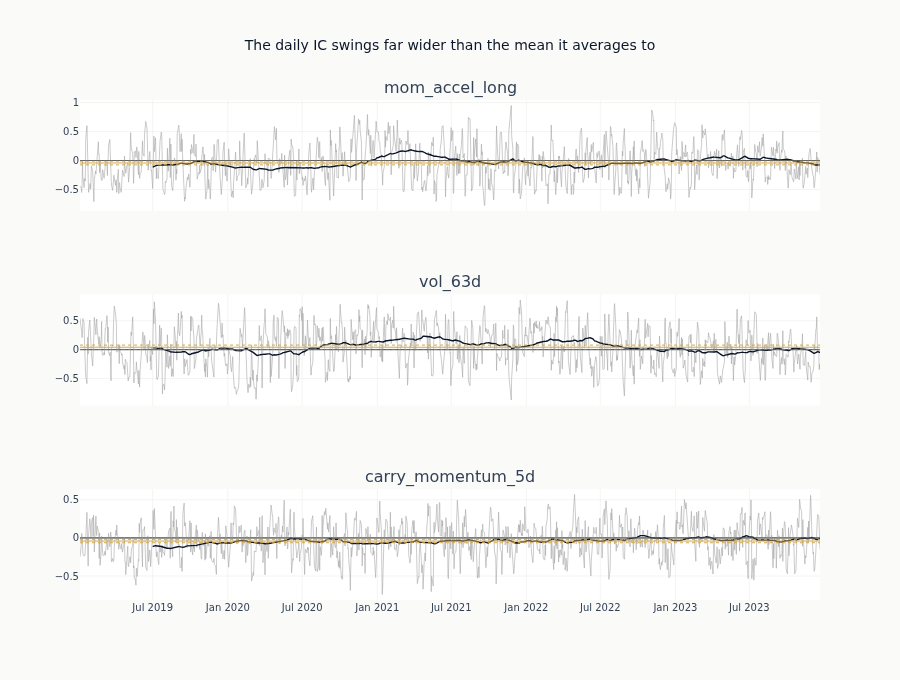

In [14]:
LEADING_FOR_SERIES = 3
ROLLING_DAYS = 126
series_features = eval_summary.head(LEADING_FOR_SERIES)["feature"].to_list()

fig = make_subplots(
    rows=len(series_features), cols=1, shared_xaxes=True, subplot_titles=series_features
)
for row, feat in enumerate(series_features, start=1):
    series = ic_timeseries[feat].sort(DATE_COL)
    bands = compute_ic_uncertainty(series, horizon=HAC_MAXLAGS, ic_col="ic")
    dates = series[DATE_COL].to_list()
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].to_list(),
            mode="lines",
            line=dict(color=GRAY_FILLS["muted"], width=0.6),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].rolling_mean(ROLLING_DAYS, min_samples=ROLLING_DAYS).to_list(),
            mode="lines",
            line=dict(color=COLORS["blue"], width=1.4),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    for value, dash in (
        (bands["mean_ic"], "solid"),
        (bands["ci_hac_lower"], "dot"),
        (bands["ci_hac_upper"], "dot"),
    ):
        fig.add_hline(y=value, line=dict(color=COLORS["amber"], width=1, dash=dash), row=row, col=1)
    fig.add_hline(y=0, line=dict(color=GRAY_FILLS["border"], width=0.8), row=row, col=1)
fig.update_layout(
    template="ml4t",
    height=200 * len(series_features) + 80,
    width=900,
    title_text="The daily IC swings far wider than the mean it averages to",
)
fig.show()

### Feature ranking, with the inference adjustment visible

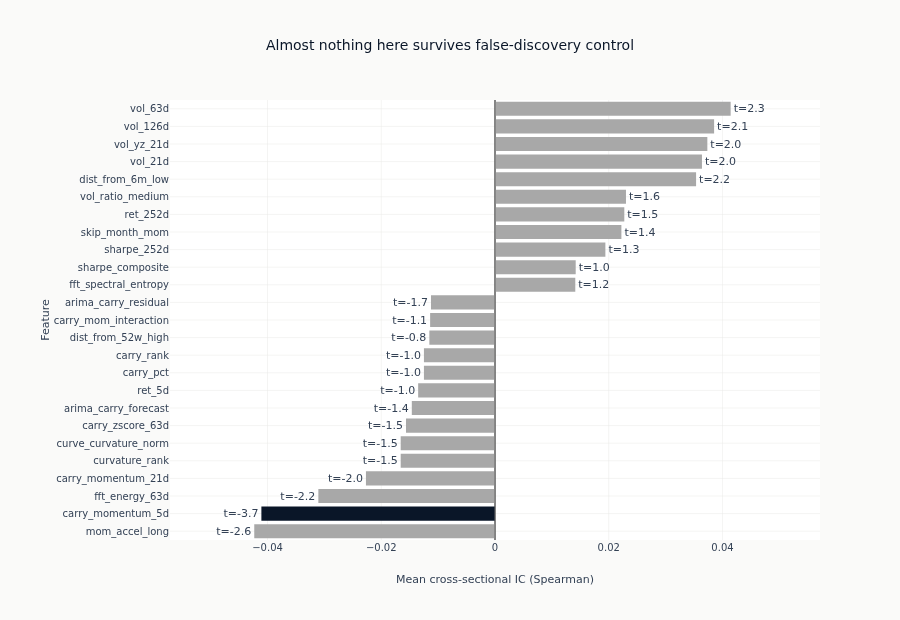

In [15]:
# Top features by absolute IC
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

# One colour convention across every figure in this section: the feature survives
# BH-FDR, or it does not. The earlier version coloured the same category green in
# one panel and red in the next.
SURVIVES, DOES_NOT = COLORS["blue"], GRAY_FILLS["muted"]

fig = go.Figure(
    go.Bar(
        x=top["ic_mean"].to_list(),
        y=top["feature"].to_list(),
        orientation="h",
        marker_color=[SURVIVES if s else DOES_NOT for s in top["fdr_sig"].to_list()],
        text=[f"t={value:.1f}" for value in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    )
)
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
# Room for the t-statistic label on the longest bar: `textposition="outside"` draws
# it past the bar end, and at the default range the leftmost one runs into the
# feature names.
ic_span = max(abs(value) for value in top["ic_mean"].to_list()) * 1.35
fig.update_layout(
    template="ml4t",
    height=620,
    width=900,
    title_text="Almost nothing here survives false-discovery control",
    xaxis_title="Mean cross-sectional IC (Spearman)",
    xaxis_range=[-ic_span, ic_span],
    yaxis_title="Feature",
    margin=dict(l=170),
)
fig.show()

### Fold-level stability

A pooled mean IC hides the difference between a feature that works in every fold
and one that had a single good year. Each feature's per-fold means are drawn with
its median marked, for the same leading features the ranking shows. The dots and
the diamond come from `per_fold_mean_ics`, the same function the screen reads, so
the median cannot be drawn over a set of folds the chart does not show.

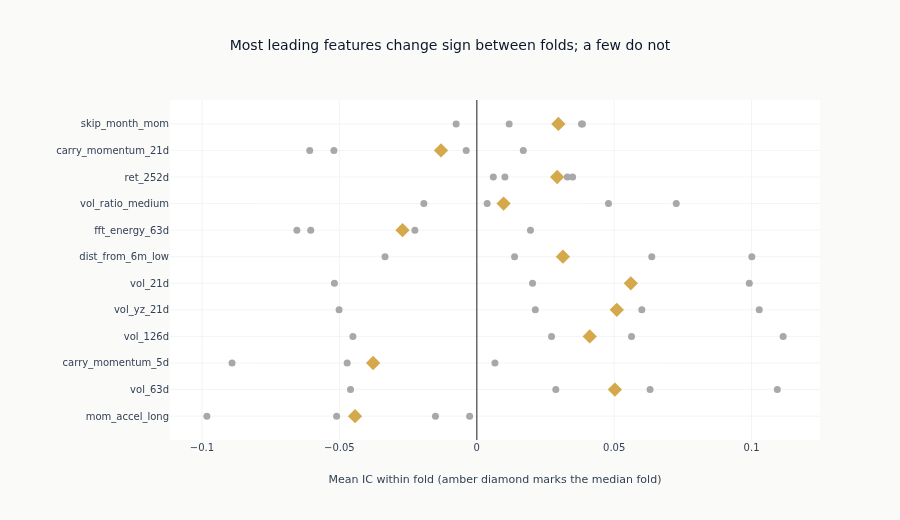

In [16]:
FOLDS_SHOWN = 12
fold_features = [f for f in eval_summary["feature"].to_list() if f in fold_stats][:FOLDS_SHOWN]
fig = go.Figure()
for feat in fold_features:
    per_fold = per_fold_mean_ics(feat)
    fig.add_trace(
        go.Scatter(
            x=per_fold,
            y=[feat] * len(per_fold),
            mode="markers",
            marker=dict(color=GRAY_FILLS["muted"], size=7),
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[fold_stats[feat]["median_fold_ic"]],
            y=[feat],
            mode="markers",
            marker=dict(color=COLORS["amber"], size=11, symbol="diamond"),
            showlegend=False,
        )
    )
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
fig.update_layout(
    template="ml4t",
    height=520,
    width=900,
    title_text="Most leading features change sign between folds; a few do not",
    xaxis_title="Mean IC within fold (amber diamond marks the median fold)",
    margin=dict(l=170),
)
fig.show()

### Naive against HAC inference

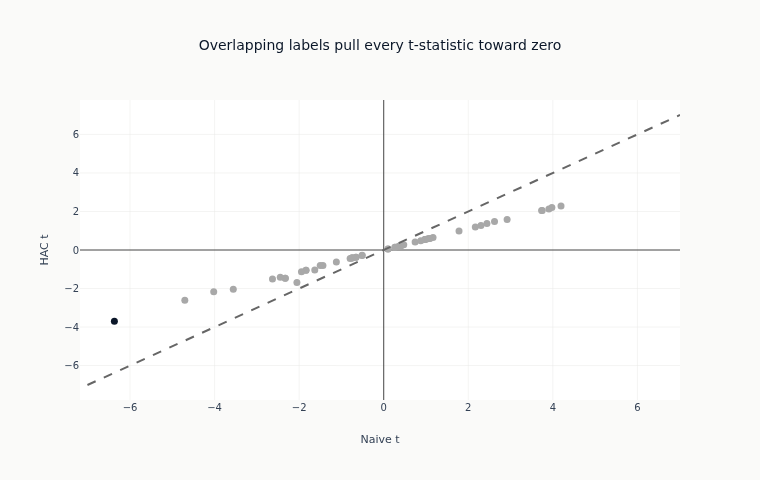

In [17]:
fig = go.Figure(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=[SURVIVES if s else DOES_NOT for s in eval_summary["fdr_sig"].to_list()],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    )
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=GRAY_FILLS["border"]),
        showlegend=False,
    )
)
fig.update_layout(
    template="ml4t",
    height=480,
    width=760,
    title_text="Overlapping labels pull every t-statistic toward zero",
    xaxis_title="Naive t",
    yaxis_title="HAC t",
)
fig.show()

**Interpretation**: points inside the 45-degree line have naive t-statistics that
the HAC correction pulls toward zero, because the overlapping label induces the
autocorrelation a raw test ignores. BH-FDR then penalizes the number of
simultaneous tests on top of that. The markers drawn in blue are the ones that
survive both corrections.

## 4. Shape Diagnostics

Quantile monotonicity asks whether the relationship between a feature and the
label is monotone — whether moving from Q1 to Q5 consistently increases or
decreases the forward return. A monotone profile is what a linear model can
use; a U-shaped one says the same information is there but not in a form a
linear coefficient can carry.

**The quantiles are formed within each date and each date is weighted equally.**
The IC beside them is a within-date rank statistic, so a profile built by
pooling every row and cutting once would be a different object: it would sort a
2011 observation against a 2023 one and let the time-series variation of the
feature stand in for the cross-sectional variation the IC measures. A feature
with a negative IC would then be free to show a rising profile with nothing to
reconcile the two.

The mean and the median profile are drawn together. The mean is what a
long-short book earns; the median describes the typical product, and a rank
statistic like the IC agrees with the median. Where they disagree the gap is the
return tail, not the shape.

In [18]:
from scipy.stats import spearmanr

# Show the FDR-significant features first, then fill up to 6 panels with the
# next-highest |IC| features so the shape diagnostic stays informative even when
# few features clear FDR (the sealed pre-holdout panel leaves only one).
fdr_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()
ranked_shape = eval_summary["feature"].to_list()
top_features_for_shape = fdr_shape + [f for f in ranked_shape if f not in fdr_shape]
top_features_for_shape = top_features_for_shape[:6]

QUANTILE_LABELS = [f"Q{i + 1}" for i in range(N_QUANTILES)]

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    # A date needs at least one product per bucket before it can be cut into them.
    valid = valid.filter(pl.len().over(DATE_COL) >= N_QUANTILES)
    if valid[DATE_COL].n_unique() < 20:
        continue
    binned = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=QUANTILE_LABELS, allow_duplicates=True)
        .over(DATE_COL)
        .alias("quantile")
    )
    # Per date first, then across dates: every date carries the same weight, which
    # is how the IC series beside this is built and how a rebalance experiences it.
    per_date = binned.group_by([DATE_COL, "quantile"]).agg(
        pl.col(label_col).mean().alias("date_mean"),
        pl.col(label_col).median().alias("date_median"),
    )
    profile = (
        per_date.group_by("quantile")
        .agg(
            pl.col("date_mean").mean().alias("mean"),
            pl.col("date_median").mean().alias("median"),
        )
        .sort("quantile")
    )
    means = profile["mean"].to_list()
    medians = profile["median"].to_list()
    quantile_spreads[feat] = {
        "q_means": means,
        "q_medians": medians,
        "spread": means[-1] - means[0],
    }

    # monotonicity in the ledger is the Spearman rank correlation between quantile
    # index and mean return, which is the convention the other case studies share.
    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

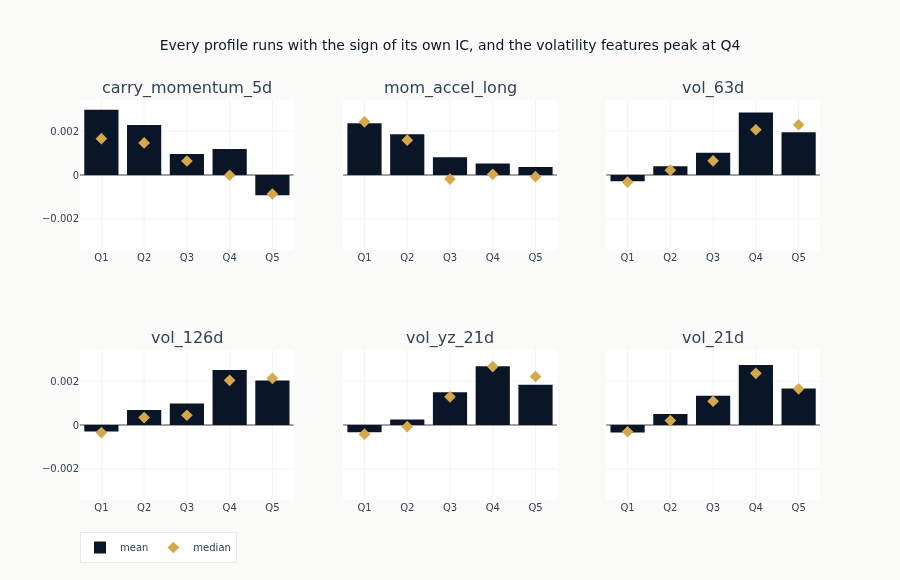

In [19]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show, shared_yaxes=True)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        fig.add_trace(
            go.Bar(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_means"],
                marker_color=COLORS["blue"],
                name="mean",
                legendgroup="mean",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
        fig.add_trace(
            go.Scatter(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_medians"],
                mode="markers",
                marker=dict(color=COLORS["amber"], size=9, symbol="diamond"),
                name="median",
                legendgroup="median",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
    # One y range across the panels: the point of six panels side by side is that
    # their heights are comparable, which independent auto-scaling destroys.
    span = max(
        abs(value)
        for feat in feats_to_show
        for key in ("q_means", "q_medians")
        for value in quantile_spreads[feat][key]
    )
    fig.update_yaxes(range=[-1.15 * span, 1.15 * span])
    fig.update_layout(
        template="ml4t",
        height=260 * n_rows_fig + 60,
        width=900,
        title_text="Every profile runs with the sign of its own IC, and the volatility features peak at Q4",
        legend=dict(orientation="h", y=-0.08),
    )
    fig.show()

**Interpretation**: a monotone profile — Q1 to Q5 consistently rising or falling —
is the shape a linear model in Ch11 can carry in a single coefficient, and every
panel here has most of one. The two negative-IC panels fall from Q1 to Q5 and the
four volatility panels rise, so each runs in the direction the ranking figure
gives it. That agreement is a consequence of forming the quantiles within each
date: cut once over the pooled panel, a feature is free to show a profile that
contradicts its own IC with nothing in the notebook to reconcile them.

What none of the volatility panels has is the last step. All four peak at Q4 and
give part of it back at Q5, which is why their monotonicity scores stop short of
1. A Ridge or Lasso coefficient fitted on the rank has to average that reversal
away; a tree in Ch12 can cut Q5 off. The median markers say the shape is not a
tail artifact — they track the means except in the middle buckets of the two
negative panels, where the mean is carried by a few large returns and the typical
product is flat.

## 5. Redundancy and Feature Families

Assign each feature to a semantic family and check for high pairwise correlation.
Redundant feature pairs (above `REDUNDANCY_CUT`) within the same family can inflate
model variance — Ch11 will address this via regularization or explicit grouping.

The family assignment function matches the one used in `03_financial_features.py`'s
inline evaluation, extended with temporal sub-families for Ch9 features.

In [20]:
def assign_feature_family(name: str) -> str:
    """Map feature name to family based on prefix/substring.

    Shared logic with 03_financial_features.py inline evaluation.
    """
    if any(k in name for k in ["carry", "curvature"]):
        return "carry"
    if name.startswith("ret_") or "mom" in name.lower():
        return "momentum"
    if name.startswith("vol_") or name in ("vr_63d",):
        return "volatility"
    if "sharpe" in name:
        return "sharpe"
    if any(name.startswith(p) for p in ["rsi", "ma_ratio", "dist_from", "ts_mom"]):
        return "technical"
    if any(k in name for k in ["month_", "quarter", "roll_", "season", "day_of_year"]):
        return "calendar"
    if any(k in name for k in ["rank", "composite", "ls_signal", "risk_adj"]):
        return "cross_sectional"
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# Override: temporal features get temporal sub-family
for feat in temporal_cols:
    if "regime" in feat.lower() or "hmm" in feat.lower():
        families[feat] = "temporal_regime"
    elif "fft" in feat.lower() or "spectral" in feat.lower():
        families[feat] = "temporal_fft"
    elif "arima" in feat.lower():
        families[feat] = "temporal_arima"
    else:
        families[feat] = "temporal_other"

In [21]:
# Pairwise correlation (sample dates for efficiency)
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print(f"Feature pairs with |corr| > {REDUNDANCY_CUT}: {len(high_corr_pairs)}")
if high_corr_pairs:
    for f1, f2, rho in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f"  {f1:30s} ↔ {f2:30s}  ρ={rho:+.3f}")

Feature pairs with |corr| > 0.7: 86
  carry_zscore_63d               ↔ arima_carry_forecast            ρ=+0.986
  vol_21d                        ↔ vol_yz_21d                      ρ=+0.978
  vol_126d                       ↔ vol_63d                         ρ=+0.972
  vol_63d                        ↔ vol_yz_21d                      ρ=+0.966
  vol_21d                        ↔ vol_63d                         ρ=+0.956
  curvature_rank                 ↔ curve_curvature_norm            ρ=+0.952
  carry_mom_interaction          ↔ carry_zscore_63d                ρ=+0.945
  vol_126d                       ↔ vol_yz_21d                      ρ=+0.942
  ret_252d                       ↔ skip_month_mom                  ρ=+0.940
  carry_mom_interaction          ↔ arima_carry_forecast            ρ=+0.932


In [22]:
# Family-level IC summary
family_ic = {}
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (7, 5)
┌────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family         ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---            ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str            ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ volatility     ┆ 7          ┆ 0.02788    ┆ 0.022618  ┆ 0         │
│ carry          ┆ 11         ┆ 0.014851   ┆ -0.013799 ┆ 1         │
│ temporal_fft   ┆ 4          ┆ 0.012969   ┆ -0.004234 ┆ 0         │
│ temporal_arima ┆ 2          ┆ 0.012943   ┆ -0.012943 ┆ 0         │
│ momentum       ┆ 13         ┆ 0.011872   ┆ 0.000204  ┆ 0         │
│ technical      ┆ 7          ┆ 0.011358   ┆ 0.005112  ┆ 0         │
│ sharpe         ┆ 7          ┆ 0.008403   ┆ 0.008403  ┆ 0         │
└────────────────┴────────────┴────────────┴───────────┴───────────┘


### Redundancy, as ranked pairs

A full correlation matrix over this many features has unreadable tick labels and
is mostly empty space. What the reader has to decide is which pairs are the same
evidence counted twice, so the strongest pairs are ranked instead, and the pair
count above `REDUNDANCY_CUT` is printed rather than written into the title.

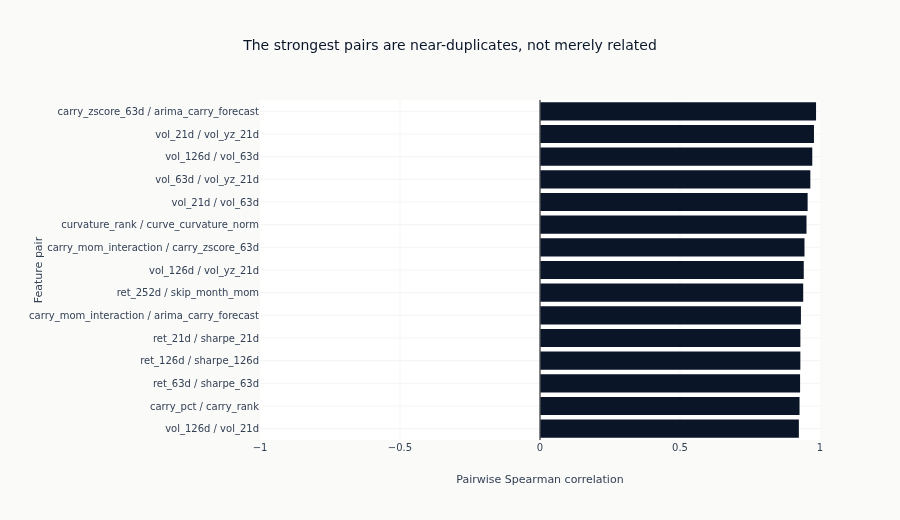

In [23]:
TOP_PAIRS = 15
ranked_pairs = sorted(high_corr_pairs, key=lambda item: -abs(item[2]))[:TOP_PAIRS]
if ranked_pairs:
    fig = go.Figure(
        go.Bar(
            x=[rho for _, _, rho in ranked_pairs][::-1],
            y=[f"{a} / {b}" for a, b, _ in ranked_pairs][::-1],
            orientation="h",
            marker_color=[
                COLORS["blue"] if rho > 0 else COLORS["copper"] for _, _, rho in ranked_pairs
            ][::-1],
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
    fig.update_layout(
        template="ml4t",
        height=520,
        width=900,
        title_text="The strongest pairs are near-duplicates, not merely related",
        xaxis_title="Pairwise Spearman correlation",
        xaxis_range=[-1, 1],
        yaxis_title="Feature pair",
        margin=dict(l=260),
    )
    fig.show()

**The carry family points the wrong way on this frame, and the screen reports
that rather than resolving it.** Every carry feature with a computable IC over the
validation windows is negative except `carry_21d`, whose HAC t-statistic leaves it
indistinguishable from zero. The strongest of them is `carry_momentum_5d`, the
five-day change in carry, and it is the one feature in the whole panel that
survives BH-FDR. Read as a sign rather than a magnitude, that says a product whose
carry has just risen underperformed one whose carry has just fallen, at the weekly
horizon, across these five validation years - the opposite direction from the
roll-yield premium that motivates the long-short carry-ranked mapping in
`setup.yaml`. A univariate screen over one window is not the instrument that
settles which is right; the ranking figure above shows the whole family with its
HAC t-statistics attached, and Ch11 sees it in a multivariate context.

## 6. Triage and Handoff

Apply triage rules to categorize each feature:

| Decision | Criteria | Arm |
|----------|----------|-----|
| **PROCEED** | BH-FDR significant at `FDR_ALPHA` | confirmation |
| **PROCEED** | sign consistency at least `MIN_SIGN_CONSISTENCY` and abs(IC) at least `IC_THRESHOLD` | exploration |
| **STOP** | correctness FAIL: coverage or staleness outside the gate | - |
| **REVISE** | everything else, to be judged in the multivariate context of Ch11 | - |

The rule is a **disjunction**, so PROCEED can exceed the count of FDR-significant
features, and the `note` column records which arm fired. The second arm is an
exploration filter in the sense of Section 7.4, not a significance test: it exists so
false-discovery control does not empty the menu on a 30-product cross-section, and
a feature promoted through it has not been confirmed. `IC_THRESHOLD` is a stated
judgement about what a weekly rebalance would need to clear its costs, not a
quantity derived from the data.

In [24]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= MIN_SIGN_CONSISTENCY and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [25]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    # Fill FDR p-values from eval_summary
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = match["fdr_p"][0]
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger: ~/ml4t/public-s15-5/case_studies/cme_futures/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 32  │
│ REVISE   ┆ 22  │
│ STOP     ┆ 15  │
└──────────┴─────┘


In [26]:
# Save IC time series (long format, reusable in Ch11)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series: ~/ml4t/public-s15-5/case_studies/cme_futures/evaluation/ic_timeseries.parquet


In [27]:
# Write results JSON
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

# Sort by absolute IC (strongest signal first, regardless of sign)
valid_ic = [(f, s) for f, s in ic_results.items() if not np.isnan(s["mean_ic"])]
sorted_by_abs_ic = sorted(valid_ic, key=lambda x: abs(x[1]["mean_ic"]), reverse=True)
strongest = sorted_by_abs_ic[0] if sorted_by_abs_ic else (None, {})
weakest = sorted_by_abs_ic[-1] if sorted_by_abs_ic else (None, {})

In [28]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in sorted(proceed_features):
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: cme_futures
  PROCEED: 32 features
  REVISE:  22 features
  STOP:    15 features

PROMOTED (PROCEED) features:
  arima_carry_forecast                      IC=-0.0146  t=-1.41  [temporal_arima]
  arima_carry_residual                      IC=-0.0113  t=-1.69  [temporal_arima]
  carry_mom_interaction                     IC=-0.0114  t=-1.12  [carry]
  carry_momentum_21d                        IC=-0.0227  t=-2.04  [carry]
  carry_momentum_5d                         IC=-0.0411  t=-3.70  [carry]
  carry_pct                                 IC=-0.0125  t=-1.05  [carry]
  carry_rank                                IC=-0.0125  t=-1.05  [carry]
  carry_zscore_63d                          IC=-0.0157  t=-1.51  [carry]
  curvature_rank                            IC=-0.0166  t=-1.47  [carry]
  curve_curvature_norm                      IC=-0.0166  t=-1.47  [carry]
  dist_from_52w_high                        IC=-0.0115  t=-0.80  [technical]
  dist_from_6m_low                          IC=

**What the triage decided, and on what.** The counts printed above are the whole
output of this notebook: a per-feature decision, with the `note` column recording
which arm promoted it. Only a small number of features clear BH-FDR on this panel,
and that is a property of the data rather than a fault in the screen - a daily
frequency on a 30-product cross-section gives each fold little statistical power,
so a single feature has to be strong to survive multiplicity correction on its
own. The exploration arm is what keeps a fold-stable, moderate-|IC| set on the
table for the multivariate models in Ch11, and the ledger says which features
reached PROCEED that way.

**PROCEED here means "not yet ruled out".** Nearly half the panel reaches it, and
almost all of that through the exploration arm rather than through BH-FDR. With
five folds the sign-consistency bar is agreement in three of them, which a coin
flip clears half the time, so the arm screens against an IC that came from a
single episode and does nothing more. The `note` column is what separates the two
populations, and Ch11 has to read it.

This notebook does not pronounce on the case study. A univariate screen is
necessary and not sufficient, and whether any of these features are tradable is
settled by a backtest Sharpe several stages later.

## Key Takeaways

1. **Report the searched set beside the p-value.** The naive, HAC and BH-FDR
   counts printed above differ by a wide margin on this panel, and the gap is
   the price of having tested every feature rather than one. A significance
   claim without the size of the search that produced it cannot be read.
2. **Read the sign, not only the magnitude.** The carry family's ICs run negative
   on this frame, the change-in-carry features most strongly, and that is the
   opposite of the direction the case study's own mapping assumes. A screen
   ranking on absolute IC alone promotes them without ever showing it.
3. **Screen on the frame where every candidate exists.** The Ch9 features are
   fitted per fold and are out of sample only inside their own validation window.
   Measured over the whole pre-holdout span their coverage is the share of it the
   folds happen to reach, and the correctness gate reads a design property as a
   broken feature; measured over the union of the windows, they are covered and
   they are comparable with the Ch8 features beside them.
4. **Fold stability is a weak filter at five folds.** Sign consistency can only
   take six values, and the bar the exploration arm sets is three folds out of
   five. It rules out the single-episode IC and it is not evidence of a stable
   association.
5. **Triage decisions** feed directly into Ch11: PROCEED features enter modeling,
   REVISE features may be included in ensembles, STOP features are excluded

**Next**: [`06_linear`](06_linear.ipynb) (Ch11) uses the triage ledger and IC time series
as inputs for Ridge/Lasso feature selection and model fitting.